In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Fix seeds

In [ ]:
import os
import numpy as np
import random
import torch


def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")


set_seed()

Random seed set as 42


## AE for embeddings

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 140


from tqdm.notebook import tqdm
from torchvision import transforms
from sklearn.manifold import TSNE

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        return self.linear2(x)

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.gelu(self.linear1(z))
        z = torch.tanh(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())

    for epoch in range(epochs):
        acc_loss = 0
        for x in tqdm(data):
            x = x.to(device)
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat)**2).sum()
            acc_loss += loss.item()
            loss.backward()
            opt.step()

        avg_loss = acc_loss / len(data)
        print(f'Epoch: {epoch + 1}/{epochs}. Train loss: {avg_loss:.3f}')
    return autoencoder

In [ ]:
class CustomMnistDataset(torch.utils.data.Dataset):
    """
    Reads the MNIST data from csv file given file path.
    """
    def __init__(self, csv_path, num_datapoints = None):
        super(CustomMnistDataset, self).__init__()

        self.df = pd.read_csv(csv_path)

        # Will be useful later while evaluating
        if num_datapoints is not None:
            self.df = self.df.iloc[0:num_datapoints]

    def __len__(self):
        return len(self.df)

    def  __getitem__(self, index):
        # Read
        img = self.df.iloc[index].filter(regex='pixel').values
        img =  np.reshape(img, (28, 28)).astype(np.uint8)

        # Convert to Tensor
        img_tensor = transforms.ToTensor()(img) # [0, 1]
        # img_tensor = 2*img_tensor - 1 # [-1, 1]
        img_tensor = transforms.Normalize((0.5,), (0.5,))(img_tensor)

        return img_tensor

In [ ]:
!unzip /content/drive/MyDrive/cursach-hse/mnist_data/train.csv.zip
!unzip /content/drive/MyDrive/cursach-hse/mnist_data/test.csv.zip

Archive:  /content/drive/MyDrive/cursach-hse/mnist_data/train.csv.zip
  inflating: train.csv               
Archive:  /content/drive/MyDrive/cursach-hse/mnist_data/test.csv.zip
  inflating: test.csv                


In [ ]:
train_csv_path = '/content/train.csv'
test_csv_path = '/content/test.csv'
batch_size = 128
latent_dims = 100

trainset = CustomMnistDataset(train_csv_path)
data = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, drop_last=True
)

In [ ]:
# latent_dims = 100

# data = torch.utils.data.DataLoader(
#         torchvision.datasets.MNIST('./data',
#                transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]),
#                download=True),
#         batch_size=128,
#         shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:11<00:00, 893kB/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 64.1kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:06<00:00, 241kB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.18MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [ ]:
ae = Autoencoder(latent_dims).to(device)
ae = train(ae, data)

  0%|          | 0/328 [00:00<?, ?it/s]

Epoch: 1/20. Train loss: 10656.089


  0%|          | 0/328 [00:00<?, ?it/s]

Epoch: 2/20. Train loss: 3478.336


  0%|          | 0/328 [00:00<?, ?it/s]

...

Epoch: 18/20. Train loss: 892.325


  0%|          | 0/328 [00:00<?, ?it/s]

Epoch: 19/20. Train loss: 877.508


  0%|          | 0/328 [00:00<?, ?it/s]

Epoch: 20/20. Train loss: 855.237


In [ ]:
torch.save(ae.state_dict(), 'ae_100dim_new.pth')

In [ ]:
fake_imgs = np.load('/content/drive/MyDrive/cursach-hse/compare_two_unseen/cfm_imgs_3000_newnew.npy')

In [ ]:
fake_imgs = torch.from_numpy(fake_imgs)

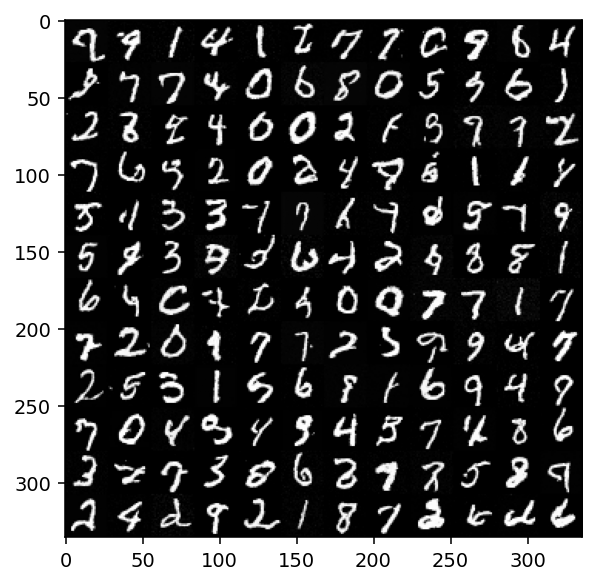

In [ ]:
n = 12
w = 28

img = np.zeros((n*w, n*w))

for i in range(n):
    for j in range(n):
        sample = fake_imgs[i + j * n]
        sample = sample.reshape(28, 28).to('cpu').detach().numpy()
        img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = sample

plt.imshow(img, cmap='gray')

In [ ]:
fake_rec = ae(fake_imgs[:200].to(device))

In [ ]:
fake_rec.shape

torch.Size([200, 1, 28, 28])

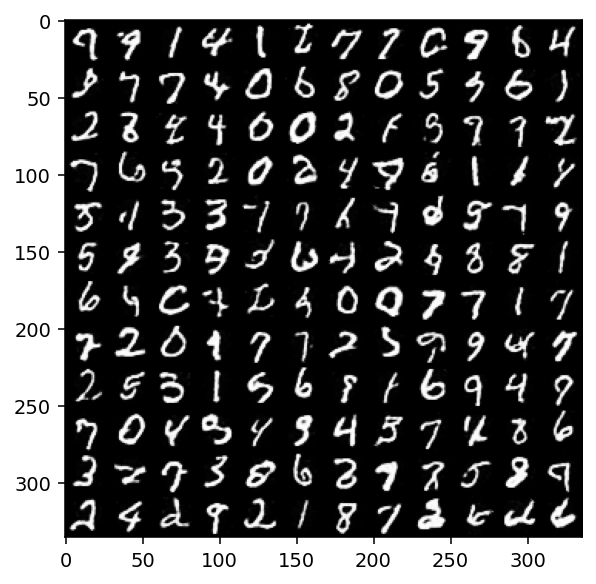

In [ ]:
n = 12
w = 28

img = np.zeros((n*w, n*w))

for i in range(n):
    for j in range(n):
        sample = fake_rec[i + j * n]
        sample = sample.reshape(28, 28).to('cpu').detach().numpy()
        img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = sample

plt.imshow(img, cmap='gray')

## t-SNE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
orig_imgs = np.load('/content/drive/MyDrive/cursach-hse/orig_imgs_5000.npy')
orig_labels = np.load('/content/drive/MyDrive/cursach-hse/orig_labels_5000.npy')
cfm_fake_imgs = np.load('/content/drive/MyDrive/cursach-hse/cfm_imgs_3000_new.npy')
ddim_fake_imgs = np.load('/content/drive/MyDrive/cursach-hse/ddim_imgs_3072.npy')

In [ ]:
orig_imgs = torch.Tensor(orig_imgs).view(5000, 28, 28)
orig_imgs = orig_imgs.to(device)

cfm_fake_imgs = torch.Tensor(cfm_fake_imgs).view(3000, 28, 28)
cfm_fake_imgs = cfm_fake_imgs.to(device)

ddim_fake_imgs = torch.Tensor(ddim_fake_imgs).view(3072, 28, 28)
ddim_fake_imgs = ddim_fake_imgs.to(device)

In [ ]:
ae = Autoencoder(100).to(device)
ae.load_state_dict(torch.load('/content/drive/MyDrive/cursach-hse/ae_100dim.pth', weights_only=True))
ae.eval()

orig_embds = ae.encoder(orig_imgs)
cfm_fake_embds = ae.encoder(cfm_fake_imgs)
ddim_fake_embds = ae.encoder(ddim_fake_imgs)

In [ ]:
fake_embds.shape, orig_embds.shape

(torch.Size([5000, 100]), torch.Size([5000, 100]))

In [ ]:
orig_embds = orig_embds.to('cpu').detach().numpy()
cfm_fake_embds = cfm_fake_embds.to('cpu').detach().numpy()
ddim_fake_embds = ddim_fake_embds.to('cpu').detach().numpy()

In [ ]:
all_embds = np.vstack([orig_embds, cfm_fake_embds])
all_embds.shape

(8000, 100)

In [ ]:
mnist_tsne_embedding = TSNE(n_components=2, perplexity=40, metric='cosine').fit_transform(all_embds)

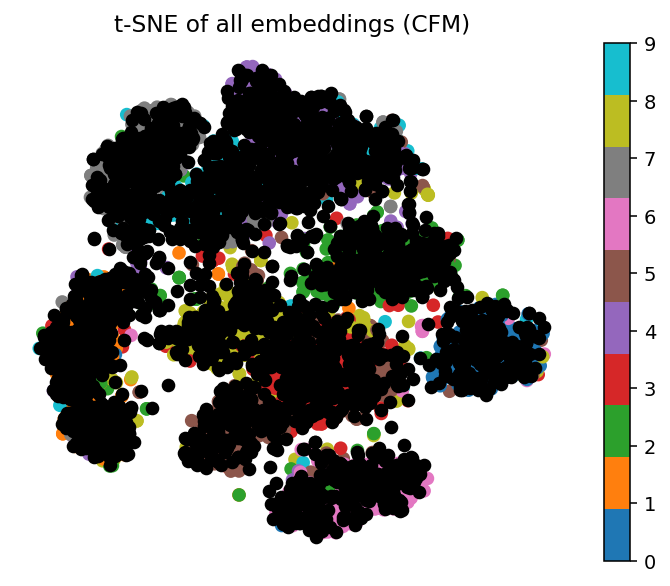

In [ ]:
plt.scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar()
plt.scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('t-SNE of all embeddings (CFM)')
# plt.show()
plt.savefig('/content/tsne_all_cfm.png')

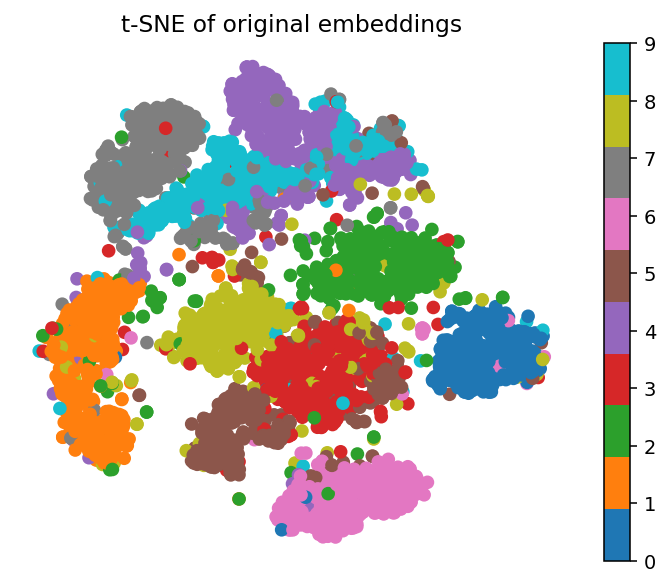

In [ ]:
plt.scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar()
# plt.scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('t-SNE of original embeddings')
# plt.show()
plt.savefig('/content/tsne_orig.png')

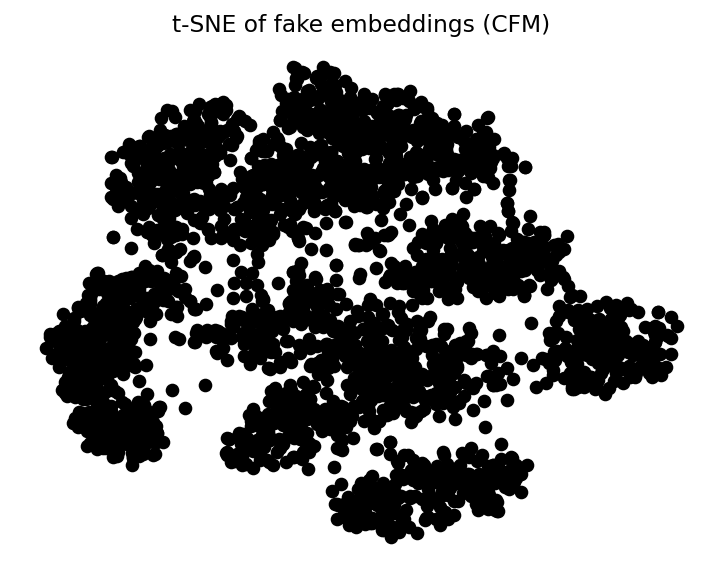

In [ ]:
# plt.scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
# plt.colorbar()
plt.scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('t-SNE of fake embeddings (CFM)')
# plt.show()
plt.savefig('/content/tsne_fake_cfm.png')

Text(0.5, 1.0, 't-SNE of fake embeddings (CFM)')

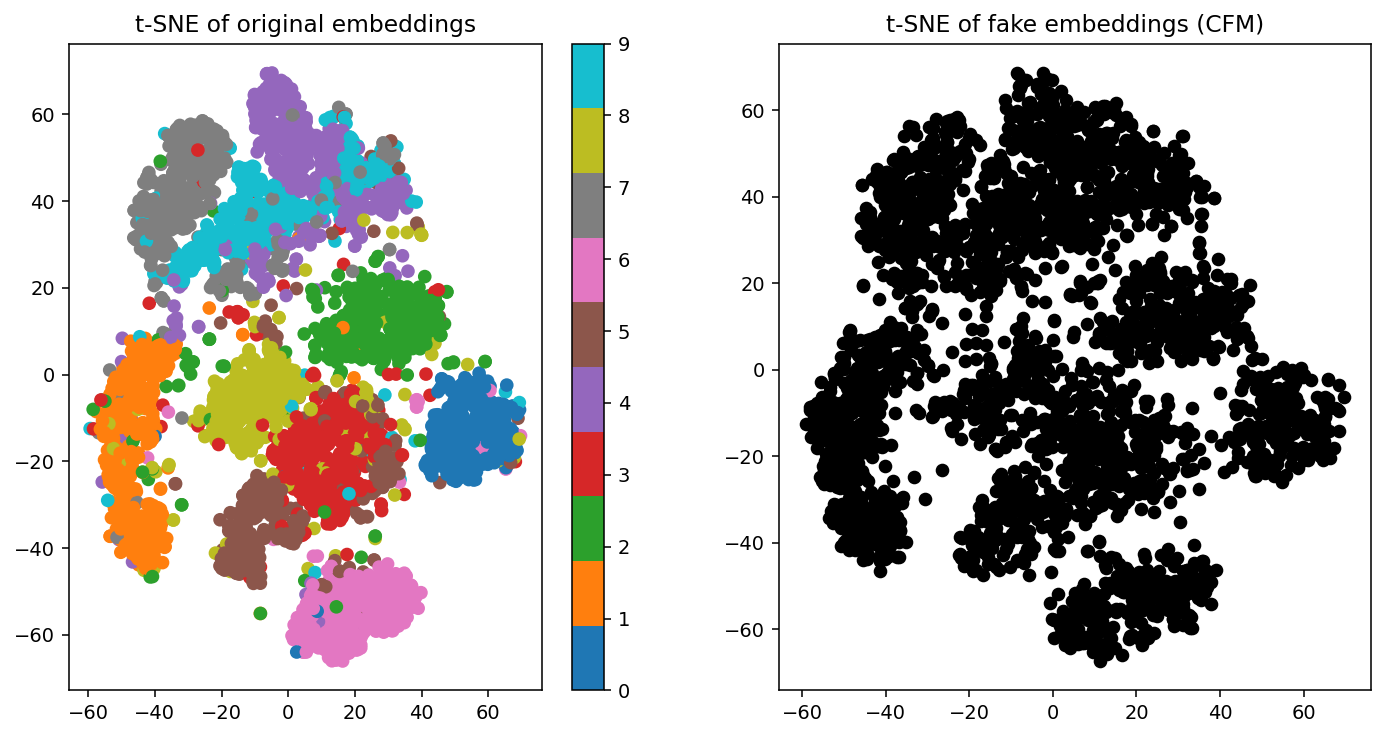

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(12, 6))
img = ax[0].scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar(img, ax=ax[0])
ax[0].set_title('t-SNE of original embeddings')
ax[1].scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
ax[1].set_title('t-SNE of fake embeddings (CFM)')

In [ ]:
!pip install umap-learn

In [ ]:
from umap.umap_ import UMAP

In [ ]:
mnist_umap_reducer = UMAP()
mnist_umap_embedding = mnist_umap_reducer.fit_transform(all_embds)
mnist_umap_embedding.shape

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(8000, 2)

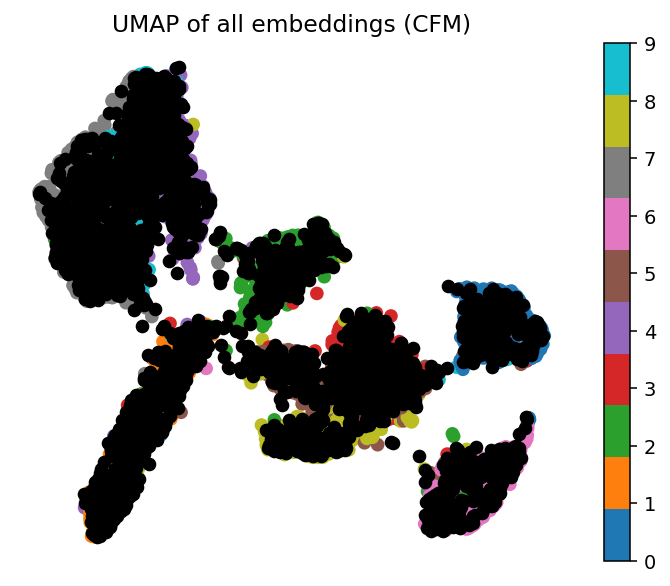

In [ ]:
plt.scatter(mnist_umap_embedding[:5000, 0], mnist_umap_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar()
plt.scatter(mnist_umap_embedding[5000:, 0], mnist_umap_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('UMAP of all embeddings (CFM)')
# plt.show()
plt.savefig('/content/umap_all_cfm.png')

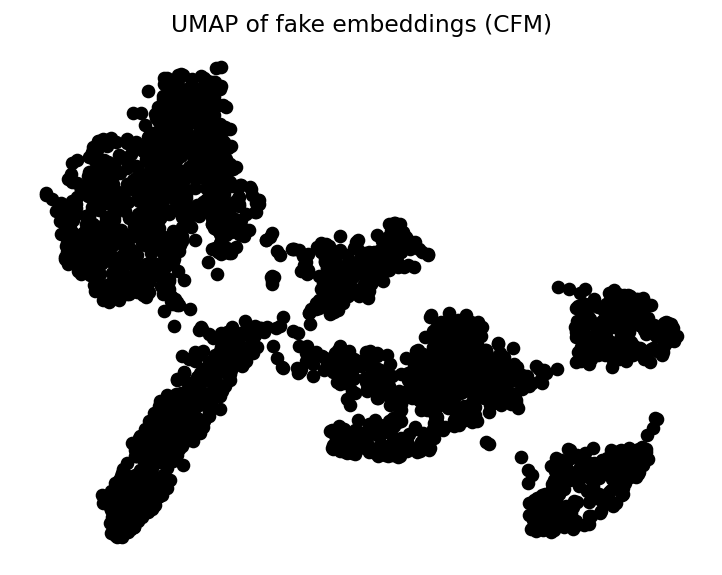

In [ ]:
# plt.scatter(mnist_umap_embedding[:5000, 0], mnist_umap_embedding[:5000, 1], c=orig_labels, cmap='tab10')
# plt.colorbar()
plt.scatter(mnist_umap_embedding[5000:, 0], mnist_umap_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('UMAP of fake embeddings (CFM)')
# plt.show()
plt.savefig('/content/umap_fake_cfm.png')

Text(0.5, 1.0, 'umap of fake embeddings')

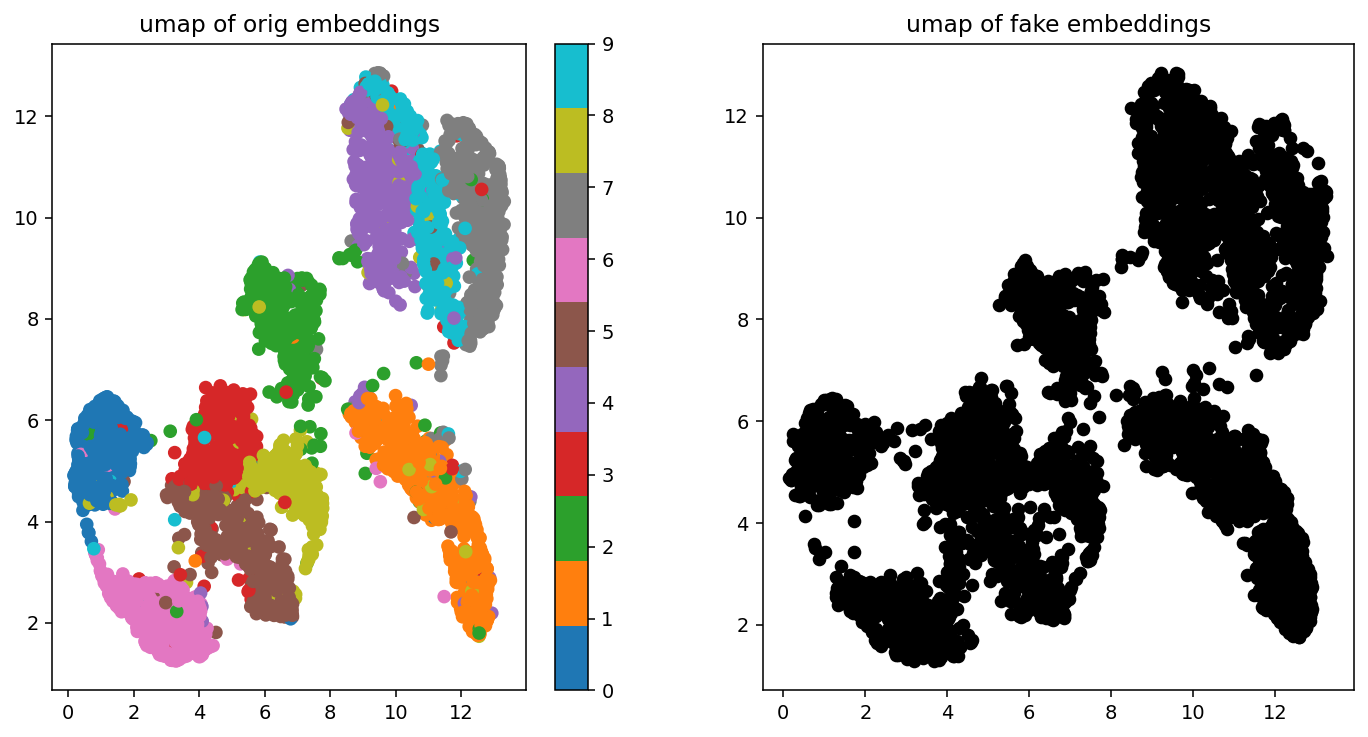

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(12, 6))
img = ax[0].scatter(mnist_umap_embedding[:5000, 0], mnist_umap_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar(img, ax=ax[0])
ax[0].set_title('umap of orig embeddings')
ax[1].scatter(mnist_umap_embedding[5000:, 0], mnist_umap_embedding[5000:, 1], color='black')
ax[1].set_title('umap of fake embeddings')

In [ ]:
all_embds = np.vstack([orig_embds, ddim_fake_embds])
all_embds.shape

(8072, 100)

In [ ]:
mnist_tsne_embedding = TSNE(n_components=2, perplexity=40, metric='cosine').fit_transform(all_embds)

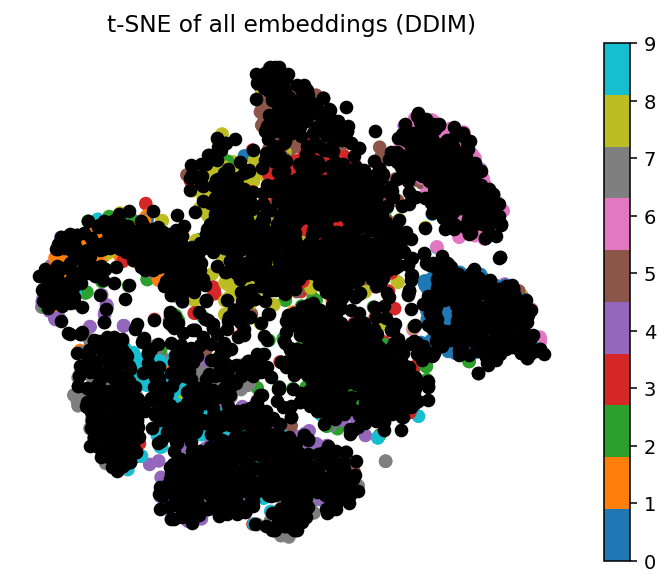

In [ ]:
plt.scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar()
plt.scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('t-SNE of all embeddings (DDIM)')
# plt.show()
plt.savefig('/content/tsne_all_ddim.png')

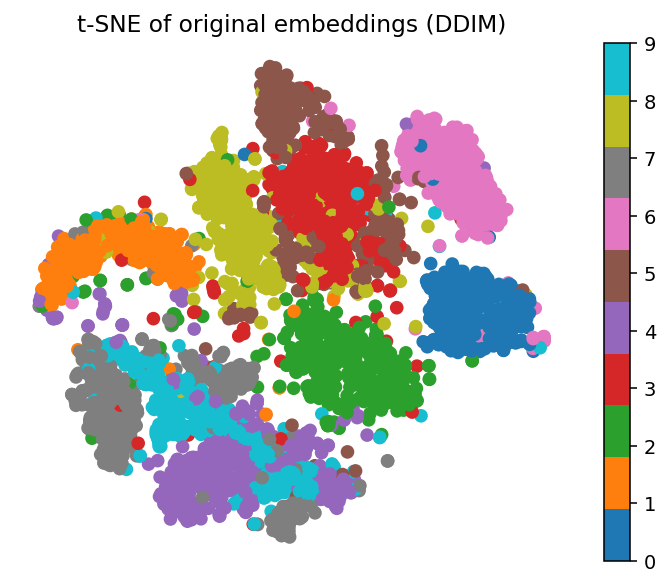

In [ ]:
plt.scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar()
# plt.scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('t-SNE of original embeddings (DDIM)')
# plt.show()
plt.savefig('/content/tsne_orig_ddim.png')

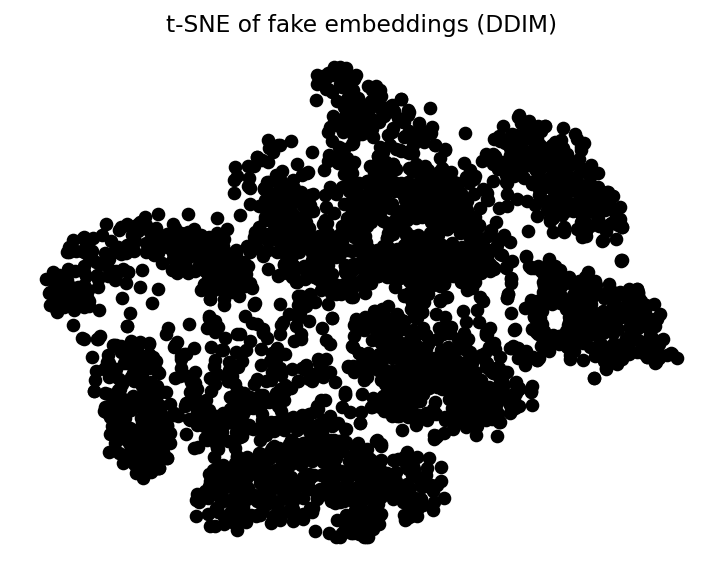

In [ ]:
# plt.scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
# plt.colorbar()
plt.scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('t-SNE of fake embeddings (DDIM)')
# plt.show()
plt.savefig('/content/tsne_fake_ddim.png')

In [ ]:
mnist_umap_reducer = UMAP()
mnist_umap_embedding = mnist_umap_reducer.fit_transform(all_embds)
mnist_umap_embedding.shape

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(8072, 2)

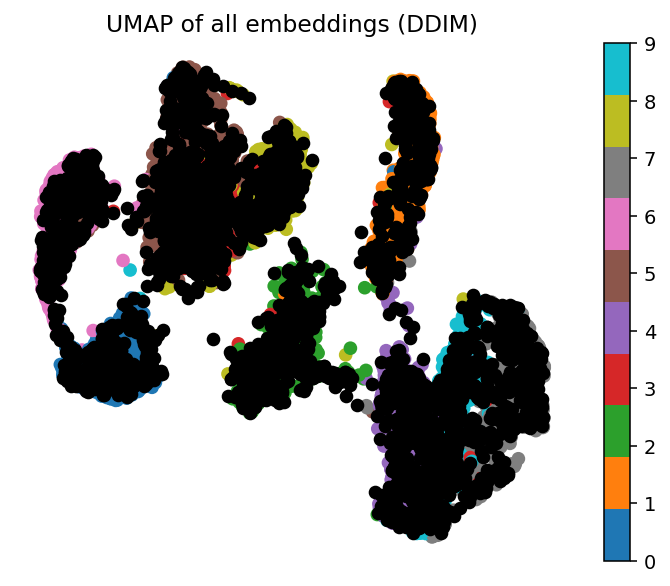

In [ ]:
plt.scatter(mnist_umap_embedding[:5000, 0], mnist_umap_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar()
plt.scatter(mnist_umap_embedding[5000:, 0], mnist_umap_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('UMAP of all embeddings (DDIM)')
# plt.show()
plt.savefig('/content/umap_all_ddim.png')

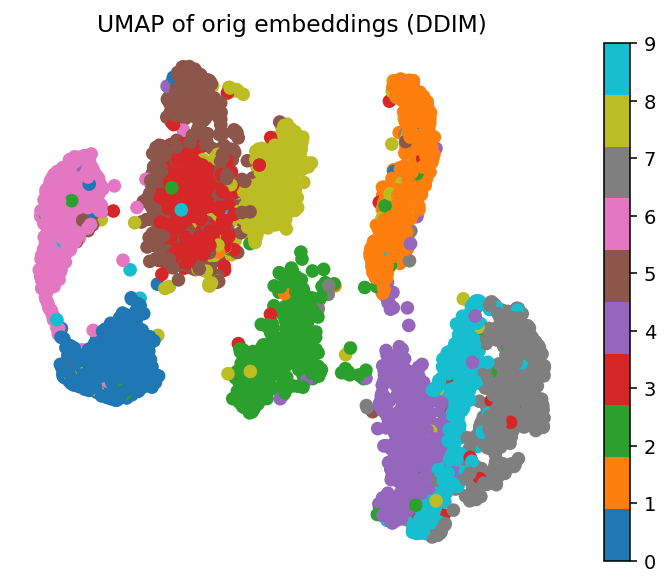

In [ ]:
plt.scatter(mnist_umap_embedding[:5000, 0], mnist_umap_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar()
# plt.scatter(mnist_umap_embedding[5000:, 0], mnist_umap_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('UMAP of orig embeddings (DDIM)')
# plt.show()
plt.savefig('/content/umap_orig_ddim.png')

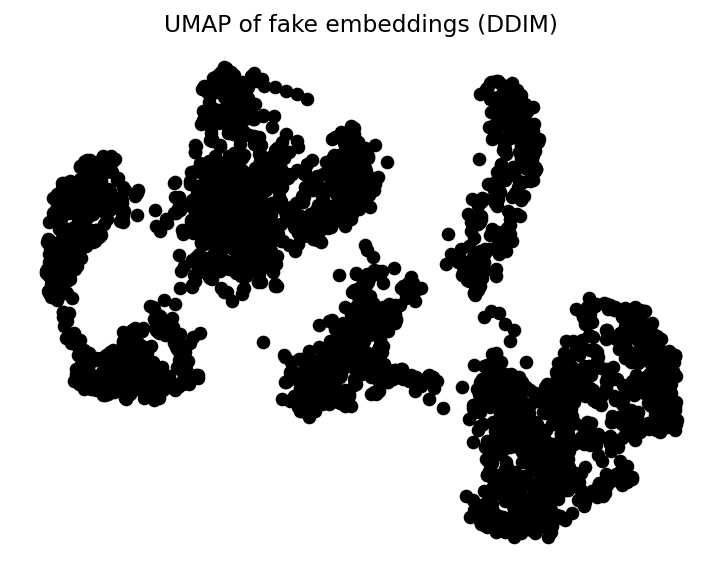

In [ ]:
# plt.scatter(mnist_umap_embedding[:5000, 0], mnist_umap_embedding[:5000, 1], c=orig_labels, cmap='tab10')
# plt.colorbar()
plt.scatter(mnist_umap_embedding[5000:, 0], mnist_umap_embedding[5000:, 1], color='black')
plt.axis('off')
plt.title('UMAP of fake embeddings (DDIM)')
# plt.show()
plt.savefig('/content/umap_fake_ddim.png')

## Diffusion

In [ ]:
orig_imgs = np.load('orig_imgs_5000.npy')
orig_labels = np.load('orig_labels_5000.npy')
ddpm_imgs = np.load('ddpm_imgs_4000.npy')

In [ ]:
orig_imgs = torch.Tensor(orig_imgs).view(5000, 28, 28)
orig_imgs = orig_imgs.to(device)

ddpm_imgs = torch.Tensor(ddpm_imgs).view(4096, 28, 28)
ddpm_imgs = ddpm_imgs.to(device)

In [ ]:
ae = Autoencoder(100).to(device)
ae.load_state_dict(torch.load('ae_100dim.pth', weights_only=True))
ae.eval()

ddpm_embds = ae.encoder(ddpm_imgs)
orig_embds = ae.encoder(orig_imgs)

In [ ]:
ddpm_embds = ddpm_embds.to('cpu').detach().numpy()
orig_embds = orig_embds.to('cpu').detach().numpy()

In [ ]:
all_embds = np.vstack([orig_embds, ddpm_embds])
all_embds.shape

(9096, 100)

In [ ]:
mnist_tsne_embedding = TSNE(n_components=2, perplexity=40, metric='cosine').fit_transform(all_embds)

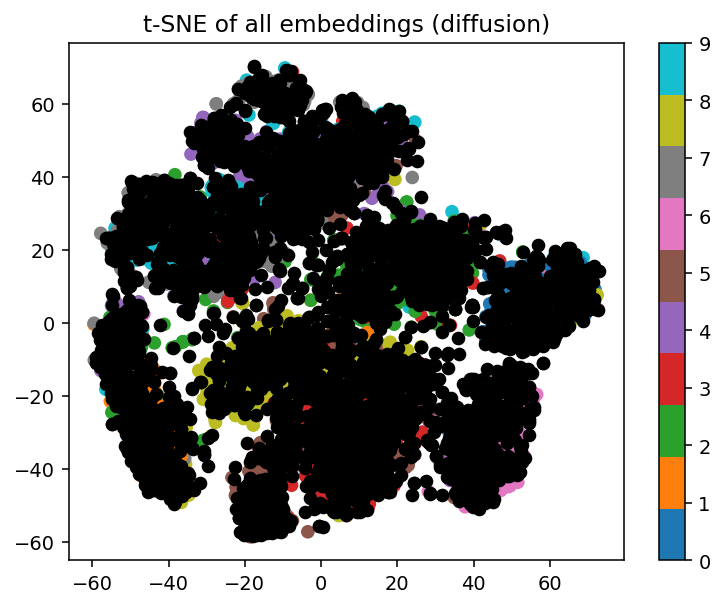

In [ ]:
plt.scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar()
plt.scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
plt.title('t-SNE of all embeddings (diffusion)')
plt.show()

Text(0.5, 1.0, 't-SNE of fake embeddings')

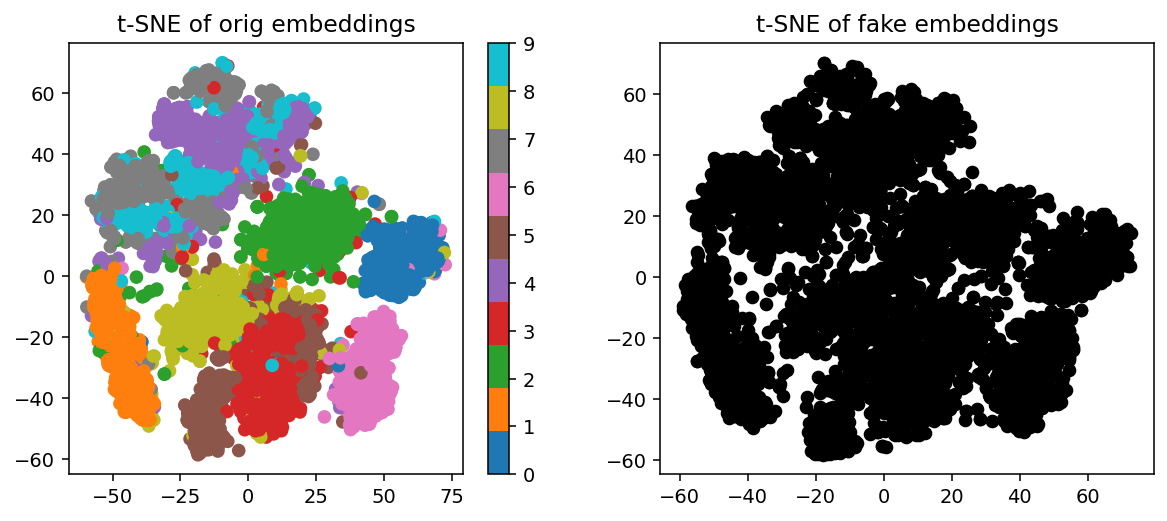

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(10, 4))
img = ax[0].scatter(mnist_tsne_embedding[:5000, 0], mnist_tsne_embedding[:5000, 1], c=orig_labels, cmap='tab10')
plt.colorbar(img, ax=ax[0])
ax[0].set_title('t-SNE of orig embeddings')
ax[1].scatter(mnist_tsne_embedding[5000:, 0], mnist_tsne_embedding[5000:, 1], color='black')
ax[1].set_title('t-SNE of fake embeddings')